# Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from pandas.core.reshape import merge
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200) # to see all output of spreadsheet

# global vars to filter dataset from START_DATE to END_DATE
START_DATE = 2016
END_DATE = 2026

In [2]:
# get datasets from github
team_df = pd.read_csv('https://raw.githubusercontent.com/sumitrodatta/bball-reference-datasets/refs/heads/master/Data/Team%20Stats%20Per%20Game.csv')
opp_df = pd.read_csv('https://raw.githubusercontent.com/sumitrodatta/bball-reference-datasets/refs/heads/master/Data/Opponent%20Stats%20Per%20Game.csv')

In [3]:
# merging the datasets
common_columns = ['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game']
merged_df = pd.merge(team_df, opp_df, on=common_columns)

#Transform into net values rather than having team and opp values
#I know there's a more efficient way to do this but I hate python syntax shenanigans so take this hardcoded blob
merged_df['net_fg_per_game'] = merged_df['fg_per_game'] - merged_df['opp_fg_per_game']
merged_df['net_fga_per_game'] = merged_df['fga_per_game'] - merged_df['opp_fga_per_game']
merged_df['net_fg_percent'] = merged_df['fg_percent'] - merged_df['opp_fg_percent']
merged_df['net_x3p_per_game'] = merged_df['x3p_per_game'] - merged_df['opp_x3p_per_game']
merged_df['net_x3pa_per_game'] = merged_df['x3pa_per_game'] - merged_df['opp_x3pa_per_game']
merged_df['net_x3p_percent'] = merged_df['x3p_percent'] - merged_df['opp_x3p_percent']
merged_df['net_x2p_per_game'] = merged_df['x2p_per_game'] - merged_df['opp_x2p_per_game']
merged_df['net_x2pa_per_game'] = merged_df['x2pa_per_game'] - merged_df['opp_x2pa_per_game']
merged_df['net_x2p_percent'] = merged_df['x2p_percent'] - merged_df['opp_x2p_percent']
merged_df['net_ft_per_game'] = merged_df['ft_per_game'] - merged_df['opp_ft_per_game']
merged_df['net_fta_per_game'] = merged_df['fta_per_game'] - merged_df['opp_fta_per_game']
merged_df['net_ft_percent'] = merged_df['ft_percent'] - merged_df['opp_ft_percent']
merged_df['net_orb_per_game'] = merged_df['orb_per_game'] - merged_df['opp_orb_per_game']
merged_df['net_drb_per_game'] = merged_df['drb_per_game'] - merged_df['opp_drb_per_game']
merged_df['net_trb_per_game'] = merged_df['trb_per_game'] - merged_df['opp_trb_per_game']
merged_df['net_ast_per_game'] = merged_df['ast_per_game'] - merged_df['opp_ast_per_game']
merged_df['net_stl_per_game'] = merged_df['stl_per_game'] - merged_df['opp_stl_per_game']
merged_df['net_blk_per_game'] = merged_df['blk_per_game'] - merged_df['opp_blk_per_game']
merged_df['net_tov_per_game'] = merged_df['tov_per_game'] - merged_df['opp_tov_per_game']
merged_df['net_pf_per_game'] = merged_df['pf_per_game'] - merged_df['opp_pf_per_game']

cols_to_drop = merged_df.loc[:, 'fg_per_game':'pf_per_game'].columns
merged_df = merged_df.drop(columns=cols_to_drop)
cols_to_drop = merged_df.loc[:, 'opp_fg_per_game':'opp_pf_per_game'].columns
merged_df = merged_df.drop(columns=cols_to_drop)

# add column for point differential
merged_df['point_diff'] = merged_df['pts_per_game'] - merged_df['opp_pts_per_game']

#These should probably be dropped as well, since point_diff is our actual dependent variable. I'm only commenting this so that I remember that I removed them
cols_to_drop = merged_df.loc[:, 'pts_per_game':'opp_pts_per_game'].columns
merged_df = merged_df.drop(columns=cols_to_drop)

# save into new .csv file
#merged_df.to_csv('Full_Basketball_Stats.csv', index=False)

#Sort by season in increasing order instead of decreasing.
merged_df = merged_df.sort_values(by=['season', 'team'])

In [4]:
# only keep NBA games
NBA_merged_df = merged_df[merged_df['lg'] == 'NBA']

In [5]:
# remove League Average statistics
NBA_merged_df = NBA_merged_df[NBA_merged_df['team'] != 'League Average']

In [6]:
# only 1980 to present
NBA_merged_df = NBA_merged_df[NBA_merged_df['season'] >= START_DATE]
NBA_merged_df = NBA_merged_df[NBA_merged_df['season'] <= END_DATE]

In [7]:
# dealing with name changes
team_mapping = {
    'Seattle SuperSonics': 'Oklahoma City Thunder',
    'New Jersey Nets': 'Brooklyn Nets',
    'Vancouver Grizzlies': 'Memphis Grizzlies',
    'San Diego Clippers': 'Los Angeles Clippers',
    'New Orleans Hornets': 'New Orleans Pelicans',
    'New Orleans/Oklahoma City Hornets': 'New Orleans Pelicans',
    'Charlotte Bobcats': 'Charlotte Hornets',
    'Washington Bullets': 'Washington Wizards',
    'Kansas City Kings': 'Sacramento Kings'
}

NBA_merged_df['team'] = NBA_merged_df['team'].replace(team_mapping)

unique_NBA_teams = sorted(NBA_merged_df['team'].unique())

In [8]:
# fix corresponding abbreviations
unique_NBA_abbr = sorted(NBA_merged_df['abbreviation'].unique())

In [9]:
abbr_mapping = {
    'SEA': 'OKC',
    'NJN': 'BRK',
    'VAN': 'MEM',
    'WSB': 'WAS',
    'KCK': 'SAC',
    'CHH': 'NOP',
    'NOH': 'NOP',
    'NOK': 'NOP',
    'CHA': 'CHO',
    'SDC': 'LAC'
}

NBA_merged_df['abbreviation'] = NBA_merged_df['abbreviation'].replace(abbr_mapping)

In [10]:
# fixing the double abbreviations for the Charlotte Hornets (complicated history)
NBA_merged_df.loc[(NBA_merged_df['team'] == 'Charlotte Hornets') & (NBA_merged_df['abbreviation'] == 'NOP'), 'team'] = 'New Orleans Pelicans'
NBA_merged_df.loc[NBA_merged_df['team'] == 'Charlotte Hornets', 'abbreviation'] = 'CHO'

In [11]:
# save the cleaned dataset
NBA_merged_df.to_csv('Cleaned_NBA_Stats.csv', index=False)

In [12]:
NBA_merged_df.head()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
310,2016,NBA,Atlanta Hawks,ATL,True,82.0,241.8,1.5,-1.7,0.026,1.6,3.9,0.012,-0.2,-5.5,0.043,-1.1,-2.1,0.028,-3.2,-1.2,-4.4,3.6,0.5,0.9,-1.1,0.8,3.6
311,2016,NBA,Boston Celtics,BOS,True,82.0,241.2,1.7,4.2,-0.002,0.9,2.8,-0.001,0.8,1.4,0.002,-1.2,-2.5,0.033,0.2,-1.3,-1.1,3.3,1.6,-1.3,-2.7,0.9,3.2
312,2016,NBA,Brooklyn Nets,BRK,False,82.0,240.9,-2.6,-0.8,-0.026,-3.0,-7.2,-0.017,0.5,6.4,-0.045,0.7,1.1,-0.006,0.3,-1.3,-1.0,-2.2,-1.2,-1.2,0.6,-0.4,-7.4
314,2016,NBA,Charlotte Hornets,CHO,True,82.0,242.1,-0.8,-0.6,-0.005,1.7,4.0,0.013,-2.5,-4.6,-0.006,2.4,2.5,0.021,0.1,-0.8,-0.8,-1.5,0.6,-0.2,-0.9,-2.3,2.7
313,2016,NBA,Chicago Bulls,CHI,False,82.0,242.7,-0.8,-2.0,0.000,0.0,-1.6,0.026,-0.8,-0.3,-0.010,0.2,-1.1,0.050,-0.7,1.1,0.4,0.3,-2.0,0.0,2.0,0.1,-1.5


In [13]:
NBA_merged_df.tail()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
25,2026,NBA,Sacramento Kings,SAC,False,61.0,241.2,-3.1,0.0,-0.035,-2.9,-5.5,-0.028,-0.3,5.5,-0.059,-1.6,-1.8,-0.008,-0.1,-3.1,-3.2,-2.5,-0.2,-0.3,0.1,1.4,-10.7
26,2026,NBA,San Antonio Spurs,SAS,False,59.0,240.4,1.5,-1.6,0.026,0.3,1.3,-0.005,1.2,-2.9,0.053,3.3,4.4,-0.007,0.6,2.6,3.2,0.6,0.1,0.8,0.2,-1.8,6.8
27,2026,NBA,Toronto Raptors,TOR,False,60.0,241.7,2.2,2.7,0.011,-1.4,-3.9,-0.002,3.7,6.6,0.002,-1.1,-1.2,-0.011,0.1,-0.8,-0.6,4.6,0.6,-0.4,-2.1,1.4,2.0
28,2026,NBA,Utah Jazz,UTA,False,60.0,242.5,-2.4,-0.6,-0.023,-2.7,-4.4,-0.026,0.3,3.8,-0.038,-0.5,-1.4,0.020,0.1,-1.3,-1.2,-0.7,-0.7,-2.5,1.6,1.1,-7.9
29,2026,NBA,Washington Wizards,WAS,False,59.0,240.8,-2.7,-2.1,-0.018,-1.4,-2.3,-0.013,-1.4,0.2,-0.027,-4.2,-4.6,-0.022,-1.8,-2.8,-4.6,-3.6,-2.0,0.6,1.8,3.4,-10.8


# Build the Feature Matrix

In [14]:
import itertools
import pandas as pd

# using the features featurewiz picked originally
selected_features = ['net_orb_per_game', 'net_ast_per_game', 'net_blk_per_game',
                     'net_pf_per_game', 'net_drb_per_game', 'net_stl_per_game']

matchup_data = []

# iterate through each season to simulate matchups
# only match teams from the SAME season
for season, group in NBA_merged_df.groupby('season'):
    teams = group['team'].unique()

    # creates all possible (Team A, Team B) pairs
    for team_a_name, team_b_name in itertools.permutations(teams, 2):
        team_a_stats = group[group['team'] == team_a_name].iloc[0]
        team_b_stats = group[group['team'] == team_b_name].iloc[0]

        # a dictionary for the new row
        row = {
            'season': season,
            'team_A': team_a_name,
            'team_B': team_b_name,
            'point_diff': team_a_stats['point_diff'] - team_b_stats['point_diff']
        }

        # add Team A's features and Team B's features
        for feat in selected_features:
            row[f'A_{feat}'] = team_a_stats[feat]
            row[f'B_{feat}'] = team_b_stats[feat]

        matchup_data.append(row)

matchup_df = pd.DataFrame(matchup_data)

print(f"New dataset created with {matchup_df.shape[0]} simulated matchups")
matchup_df.head()

New dataset created with 9570 simulated matchups!


,season,team_A,team_B,point_diff,A_net_orb_per_game,B_net_orb_per_game,A_net_ast_per_game,B_net_ast_per_game,A_net_blk_per_game,B_net_blk_per_game,A_net_pf_per_game,B_net_pf_per_game,A_net_drb_per_game,B_net_drb_per_game,A_net_stl_per_game,B_net_stl_per_game
0,2016,Atlanta Hawks,Boston Celtics,0.4,-3.2,0.2,3.6,3.3,0.9,-1.3,0.8,0.9,-1.2,-1.3,0.5,1.6
1,2016,Atlanta Hawks,Brooklyn Nets,11.0,-3.2,0.3,3.6,-2.2,0.9,-1.2,0.8,-0.4,-1.2,-1.3,0.5,-1.2
2,2016,Atlanta Hawks,Charlotte Hornets,0.9,-3.2,0.1,3.6,-1.5,0.9,-0.2,0.8,-2.3,-1.2,-0.8,0.5,0.6
3,2016,Atlanta Hawks,Chicago Bulls,5.1,-3.2,-0.7,3.6,0.3,0.9,0.0,0.8,0.1,-1.2,1.1,0.5,-2.0
4,2016,Atlanta Hawks,Cleveland Cavaliers,-2.4,-3.2,1.3,3.6,1.3,0.9,-0.5,0.8,-0.3,-1.2,2.1,0.5,-0.5


In [15]:
# we don't need to know team a and team b from here on out
matchup_df = matchup_df.drop(['team_A'], axis=1)
matchup_df = matchup_df.drop(['team_B'], axis=1)

In [16]:
matchup_df.head()

,season,point_diff,A_net_orb_per_game,B_net_orb_per_game,A_net_ast_per_game,B_net_ast_per_game,A_net_blk_per_game,B_net_blk_per_game,A_net_pf_per_game,B_net_pf_per_game,A_net_drb_per_game,B_net_drb_per_game,A_net_stl_per_game,B_net_stl_per_game
0,2016,0.4,-3.2,0.2,3.6,3.3,0.9,-1.3,0.8,0.9,-1.2,-1.3,0.5,1.6
1,2016,11.0,-3.2,0.3,3.6,-2.2,0.9,-1.2,0.8,-0.4,-1.2,-1.3,0.5,-1.2
2,2016,0.9,-3.2,0.1,3.6,-1.5,0.9,-0.2,0.8,-2.3,-1.2,-0.8,0.5,0.6
3,2016,5.1,-3.2,-0.7,3.6,0.3,0.9,0.0,0.8,0.1,-1.2,1.1,0.5,-2.0
4,2016,-2.4,-3.2,1.3,3.6,1.3,0.9,-0.5,0.8,-0.3,-1.2,2.1,0.5,-0.5


In [17]:
# split into training and test (seen and unseen)
test = matchup_df[matchup_df['season'] == 2026]
training = matchup_df[matchup_df['season'] < 2026]

In [18]:
# now we can delete season
matchup_df = matchup_df.drop(['season'], axis=1)
test = test.drop(['season'], axis=1)
training = training.drop(['season'], axis=1)

In [19]:
# define X_train, X_test, y_train, y_test
X_train = training.drop(columns=['point_diff'])
X_test = test.drop(columns=['point_diff'])
y_train = training['point_diff']
y_test = test['point_diff']

In [20]:
# the repeated values for Team A makes sense since they are being matched up against different teams multiple times
X_train.head()

,A_net_orb_per_game,B_net_orb_per_game,A_net_ast_per_game,B_net_ast_per_game,A_net_blk_per_game,B_net_blk_per_game,A_net_pf_per_game,B_net_pf_per_game,A_net_drb_per_game,B_net_drb_per_game,A_net_stl_per_game,B_net_stl_per_game
0,-3.2,0.2,3.6,3.3,0.9,-1.3,0.8,0.9,-1.2,-1.3,0.5,1.6
1,-3.2,0.3,3.6,-2.2,0.9,-1.2,0.8,-0.4,-1.2,-1.3,0.5,-1.2
2,-3.2,0.1,3.6,-1.5,0.9,-0.2,0.8,-2.3,-1.2,-0.8,0.5,0.6
3,-3.2,-0.7,3.6,0.3,0.9,0.0,0.8,0.1,-1.2,1.1,0.5,-2.0
4,-3.2,1.3,3.6,1.3,0.9,-0.5,0.8,-0.3,-1.2,2.1,0.5,-0.5


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer

# used to transform on ALL data excluding point_diff
input_features = matchup_df.columns[1:]

# define scaler
scaler = make_column_transformer(
    (StandardScaler(), input_features),
    remainder='passthrough'
)

# fit only on training
scaler.fit(X_train)

# scale rest of datasets NOT ground truth
scaled_X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
scaled_X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [22]:
y_test.tail()

,point_diff
9565,-8.2
9566,-0.1
9567,-17.6
9568,-12.8
9569,-2.9


# Train and Test

## Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

linearModel = LinearRegression()
linearModel.fit(X_train, y_train)

# save the model
joblib.dump(linearModel, 'LinRegModel.joblib')

['LinRegModel.joblib']

Accuracy of model on training set:  0.8243245856745105
Accuracy of model on test set:  0.8949717132944226
MSE: 6.91374893950055, R2: 0.8949717132944226


<Axes: xlabel='y', ylabel='y_pred'>

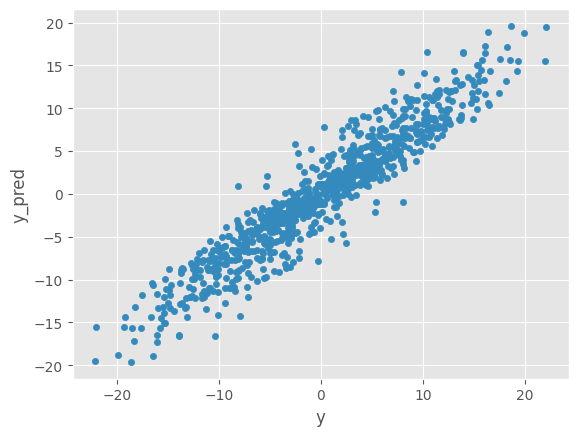

In [24]:
# predict on test set (unseen)
y_pred = linearModel.predict(X_test)

# metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Accuracy of model on training set: ", linearModel.score(X_train,y_train))
print("Accuracy of model on test set: ", linearModel.score(X_test,y_test))
print("MSE: {}, R2: {}".format(mse, r2))

df = pd.DataFrame({
    'y': y_test,
    'y_pred': y_pred
})
df.plot.scatter(x='y', y = 'y_pred')

In [25]:
# Can this model predict Sacramento Kings vs Phoenix Suns? Yes, not the exact point differential but it correctly predicts that Sac loses

# these are values BEFORE the actual game happened irl, NOT seen in training
# the order is safe, the UserWarning is only thrown bc it was put through as a numpy arr without col names but the values are inputted correctly
knicks_v_raptors = {
    'A_net_orb_per_game': [12.8 - 10.1], 'B_net_orb_per_game': [11.2 - 11.1],
    'A_net_ast_per_game': [27.2 - 24.6], 'B_net_ast_per_game': [29.0 - 24.6],
    'A_net_blk_per_game': [4.1 - 4.6], 'B_net_blk_per_game': [4.8 - 5.3],
    'A_net_pf_per_game': [20.3 - 19.3],   'B_net_pf_per_game': [20.8 - 19.4],
    'A_net_drb_per_game': [33.1 - 31.4],   'B_net_drb_per_game': [31.4 - 32.4],
    'A_net_stl_per_game': [8.1 - 7.2], 'B_net_stl_per_game': [8.6 - 8.0]
}

sac_v_phoenix = {
    'A_net_orb_per_game': [11.2 - 11.3], 'B_net_orb_per_game': [13.1 - 12.2],
    'A_net_ast_per_game': [25.1 - 27.6], 'B_net_ast_per_game': [24.5 - 24.7],
    'A_net_blk_per_game': [4.5 - 4.8], 'B_net_blk_per_game': [4 - 4.6],
    'A_net_pf_per_game': [20 - 18.6],   'B_net_pf_per_game': [21.1 - 18.6],
    'A_net_drb_per_game': [30.3 - 33.4],   'B_net_drb_per_game': [30.2 - 32.2],
    'A_net_stl_per_game': [8.4 - 8.6], 'B_net_stl_per_game': [24.5 - 24.7]
}

input_df = pd.DataFrame(sac_v_phoenix)

# SCALE THE DATA so that it matches training features
input_scaled = scaler.transform(input_df)

# PREDICT
game_pred = linearModel.predict(input_scaled)

print(f"Predicted Point Differential: {game_pred[0]}")

Predicted Point Differential: -0.6026468401590248


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Random Forest

In [26]:
from sklearn.ensemble import RandomForestRegressor

forestModel = RandomForestRegressor(n_estimators=100, random_state=0)
forestModel.fit(X_train, y_train)

# save the model
joblib.dump(forestModel, 'RandForestModel.joblib')

['RandForestModel.joblib']

Accuracy of model on training set:  0.9880006427839985
Accuracy of model on test set:  0.850716807898457
MSE: 9.826938470114934, R2: 0.850716807898457


<Axes: xlabel='y', ylabel='y_pred'>

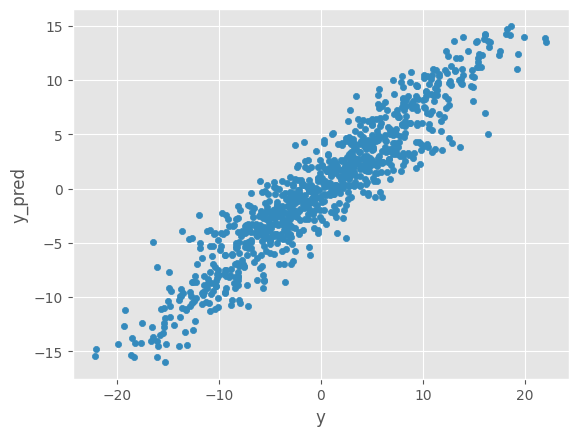

In [27]:
# predict on test set (unseen)
y_pred = forestModel.predict(X_test)

# metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Accuracy of model on training set: ", forestModel.score(X_train,y_train))
print("Accuracy of model on test set: ", forestModel.score(X_test,y_test))
print("MSE: {}, R2: {}".format(mse, r2))

df = pd.DataFrame({
    'y': y_test,
    'y_pred': y_pred
})
df.plot.scatter(x='y', y = 'y_pred')

In [28]:
# Can this model predict Sacramento Kings vs Phoenix Suns? Yes, not the exact point differential but it correctly predicts that Sac loses

# these are values BEFORE the actual game happened irl, NOT seen in training
# the order is safe, the UserWarning is only thrown bc it was put through as a numpy arr without col names but the values are inputted correctly
knicks_v_raptors = {
    'A_net_orb_per_game': [12.8 - 10.1], 'B_net_orb_per_game': [11.2 - 11.1],
    'A_net_ast_per_game': [27.2 - 24.6], 'B_net_ast_per_game': [29.0 - 24.6],
    'A_net_blk_per_game': [4.1 - 4.6], 'B_net_blk_per_game': [4.8 - 5.3],
    'A_net_pf_per_game': [20.3 - 19.3],   'B_net_pf_per_game': [20.8 - 19.4],
    'A_net_drb_per_game': [33.1 - 31.4],   'B_net_drb_per_game': [31.4 - 32.4],
    'A_net_stl_per_game': [8.1 - 7.2], 'B_net_stl_per_game': [8.6 - 8.0]
}

sac_v_phoenix = {
    'A_net_orb_per_game': [11.2 - 11.3], 'B_net_orb_per_game': [13.1 - 12.2],
    'A_net_ast_per_game': [25.1 - 27.6], 'B_net_ast_per_game': [24.5 - 24.7],
    'A_net_blk_per_game': [4.5 - 4.8], 'B_net_blk_per_game': [4 - 4.6],
    'A_net_pf_per_game': [20 - 18.6],   'B_net_pf_per_game': [21.1 - 18.6],
    'A_net_drb_per_game': [30.3 - 33.4],   'B_net_drb_per_game': [30.2 - 32.2],
    'A_net_stl_per_game': [8.4 - 8.6], 'B_net_stl_per_game': [24.5 - 24.7]
}

input_df = pd.DataFrame(sac_v_phoenix)

# SCALE THE DATA so that it matches training features
input_scaled = scaler.transform(input_df)

# PREDICT
game_pred = forestModel.predict(input_scaled)

print(f"Predicted Point Differential: {game_pred[0]}")

Predicted Point Differential: -1.7100000000000015


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## Ridge Regression

In [29]:
from sklearn.linear_model import Ridge

ridgeModel = Ridge(alpha = 1)
ridgeModel.fit(X_train, y_train)

# save the model
joblib.dump(ridgeModel, 'RidgeRegModel.joblib')

['RidgeRegModel.joblib']

Accuracy of model on training set:  0.8243245818347107
Accuracy of model on test set:  0.8949738022335668
MSE: 6.913611429871039, R2: 0.8949738022335668


<Axes: xlabel='y', ylabel='y_pred'>

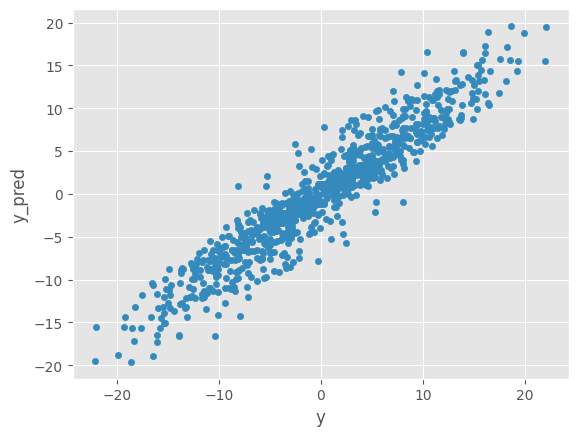

In [30]:
# predict on test set (unseen)
y_pred = ridgeModel.predict(X_test)

# metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Accuracy of model on training set: ", ridgeModel.score(X_train,y_train))
print("Accuracy of model on test set: ", ridgeModel.score(X_test,y_test))
print("MSE: {}, R2: {}".format(mse, r2))

df = pd.DataFrame({
    'y': y_test,
    'y_pred': y_pred
})
df.plot.scatter(x='y', y = 'y_pred')

In [31]:
# Can this model predict Sacramento Kings vs Phoenix Suns? Yes, not the exact point differential but it correctly predicts that Sac loses

# these are values BEFORE the actual game happened irl, NOT seen in training
# the order is safe, the UserWarning is only thrown bc it was put through as a numpy arr without col names but the values are inputted correctly
knicks_v_raptors = {
    'A_net_orb_per_game': [12.8 - 10.1], 'B_net_orb_per_game': [11.2 - 11.1],
    'A_net_ast_per_game': [27.2 - 24.6], 'B_net_ast_per_game': [29.0 - 24.6],
    'A_net_blk_per_game': [4.1 - 4.6], 'B_net_blk_per_game': [4.8 - 5.3],
    'A_net_pf_per_game': [20.3 - 19.3],   'B_net_pf_per_game': [20.8 - 19.4],
    'A_net_drb_per_game': [33.1 - 31.4],   'B_net_drb_per_game': [31.4 - 32.4],
    'A_net_stl_per_game': [8.1 - 7.2], 'B_net_stl_per_game': [8.6 - 8.0]
}

sac_v_phoenix = {
    'A_net_orb_per_game': [11.2 - 11.3], 'B_net_orb_per_game': [13.1 - 12.2],
    'A_net_ast_per_game': [25.1 - 27.6], 'B_net_ast_per_game': [24.5 - 24.7],
    'A_net_blk_per_game': [4.5 - 4.8], 'B_net_blk_per_game': [4 - 4.6],
    'A_net_pf_per_game': [20 - 18.6],   'B_net_pf_per_game': [21.1 - 18.6],
    'A_net_drb_per_game': [30.3 - 33.4],   'B_net_drb_per_game': [30.2 - 32.2],
    'A_net_stl_per_game': [8.4 - 8.6], 'B_net_stl_per_game': [24.5 - 24.7]
}

input_df = pd.DataFrame(sac_v_phoenix)

# SCALE THE DATA so that it matches training features
input_scaled = scaler.transform(input_df)

# PREDICT
game_pred = ridgeModel.predict(input_scaled)

print(f"Predicted Point Differential: {game_pred[0]}")

Predicted Point Differential: -0.6026726271146994


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
